# M2 — Baseline (1D Feature Extraction)

Goal: train and compare interpretable per-cloud classifiers on the engineered feature
vectors from `notebooks/02_feature_engineering.ipynb`, per `ROADMAP.md` M2.

Model training/selection lives in `src/baseline.py`, metrics live in `src/metrics.py` —
this notebook trains, visualizes, and picks a winner. The frozen **test** split is not
touched anywhere in this notebook; only train (fit) and val (compare/select) are used,
same discipline as `01_eda.ipynb` and `02_feature_engineering.ipynb`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import CLASSES, get_splits
from src.features import build_feature_matrix
from src.baseline import get_models, train_and_evaluate, select_best
from src.metrics import evaluate

## 1. Train both candidate models

`get_models()` returns a Random Forest and an SVM (wrapped in a `StandardScaler`, since
SVM is distance-based and the feature columns have very different scales — see
`src/baseline.py`). Both use `class_weight="balanced"` to offset the ~3.6:1 class
imbalance documented in `01_eda.ipynb`. `train_and_evaluate` fits each on the train split
and evaluates on val.

In [2]:
splits = get_splits()
results = train_and_evaluate(splits=splits)
list(results.keys())

['random_forest', 'svm']

## 2. Compare weighted metrics

Weighted precision/recall/IoU average each class's score by how many val samples it has
(see `src/metrics.py` docstring) — the same convention as scikit-learn's
`average="weighted"`, and appropriate here given the class imbalance.

In [3]:
comparison = pd.DataFrame({
    name: {"accuracy": r["report"]["accuracy"], **r["report"]["weighted"]}
    for name, r in results.items()
}).T
comparison

,accuracy,precision,recall,iou
random_forest,0.765258,0.755367,0.765258,0.629163
svm,0.647887,0.631598,0.647887,0.491604


## 3. Confusion matrices

Where the two models actually disagree, and with which classes, is more informative than
a single aggregate score.

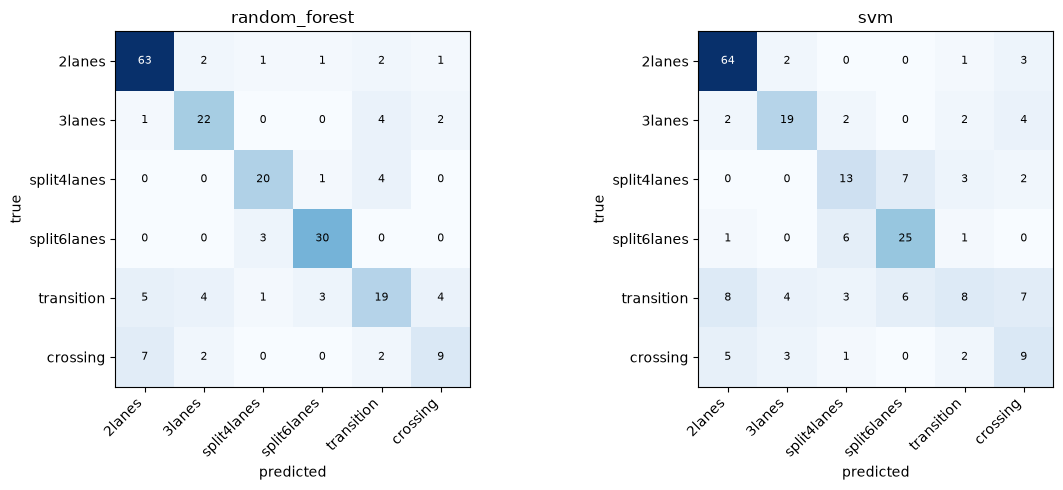

In [4]:
def plot_confusion_matrix(cm, class_names, ax, title):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    threshold = cm.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                     color="white" if cm[i, j] > threshold else "black")
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, result) in zip(axes, results.items()):
    plot_confusion_matrix(result["report"]["confusion_matrix"], CLASSES, ax, name)
plt.tight_layout()
plt.show()

## 4. Per-class IoU

IoU penalizes both false positives and false negatives for a class at once, so it is the
most informative single per-class number here — a class can have decent recall and still
score a low IoU if the model also over-predicts it for other classes.

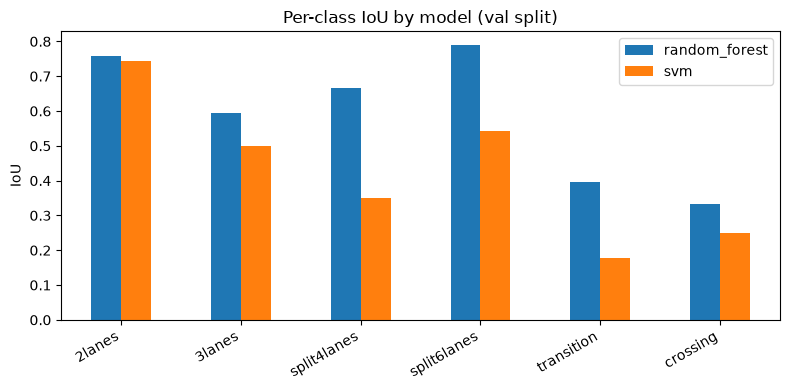

In [5]:
iou_table = pd.DataFrame({
    name: [r["report"]["per_class"][c]["iou"] for c in CLASSES]
    for name, r in results.items()
}, index=CLASSES)

fig, ax = plt.subplots(figsize=(8, 4))
iou_table.plot.bar(ax=ax)
ax.set_ylabel("IoU")
ax.set_title("Per-class IoU by model (val split)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Observation:** `transition` and `crossing` have the lowest IoU for both models — consistent
with `02_feature_engineering.ipynb` §2, where `x_range` (the strongest single engineered
feature) failed to cleanly separate exactly these classes from the rest. `2lanes` and
`split6lanes`, at the extremes of the width distribution, are the easiest for both models.
This is the clearest sign yet that a scalar feature vector is running into a real ceiling
for the classes that don't reduce to "how wide is this tile" — the motivation for M3's
BEV/CNN approach, which sees the full spatial layout instead.

## 5. Sanity-check `src/metrics.py` against scikit-learn

`src/metrics.py` computes precision/recall/IoU directly from the confusion matrix instead
of calling `sklearn.metrics`, so the formulas are visible (per `CLAUDE.md`'s "avoid
black-box solutions"). Cross-checking against sklearn's own implementation here catches
any mistake in that hand-rolled version.

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, jaccard_score

X_val, y_val, _ = build_feature_matrix(splits["val"])
for name, result in results.items():
    y_pred = result["model"].predict(X_val)
    sklearn_scores = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_val, y_pred, average="weighted", zero_division=0),
        "iou": jaccard_score(y_val, y_pred, average="weighted", zero_division=0),
    }
    mine = {"accuracy": result["report"]["accuracy"], **result["report"]["weighted"]}
    matches = all(abs(sklearn_scores[k] - mine[k]) < 1e-9 for k in sklearn_scores)
    print(f"{name}: matches sklearn = {matches}")

random_forest: matches sklearn = True
svm: matches sklearn = True


## 6. Select the best baseline model

`select_best` (in `src/baseline.py`) picks the model with the highest weighted IoU on the
val split — the strictest of the three weighted metrics, since it is hurt by both
precision and recall errors at once.

In [7]:
best_name = select_best(results)
best_name

'random_forest'

**Selected baseline: `random_forest`** — accuracy 0.765, weighted IoU
0.629 on the val split.

## 7. Next steps

Remaining M2 items are done: features engineered (`02_feature_engineering.ipynb`), models
trained and evaluated (`accuracy`, `precision`, `recall`, `IoU`, weighted & per-class),
best baseline selected. From here (per `ROADMAP.md`):

- **M3** implements the BEV converter and a CNN, and compares against `random_forest`'s
  numbers above on the same val split and the same metrics (`src/metrics.py` is written to
  be model-agnostic for exactly this reason).
- The confusion matrices and per-class IoU above are the concrete baseline to beat,
  especially for `transition`/`crossing`, where M3's access to the full spatial layout
  should help most.
- The frozen test split is still untouched — first and only use is M5's final evaluation.